# Playlist Data Exploration

Exploring the Anna's Archive Spotify playlist dataset (6.6M playlists, 1.7B track entries) to determine filtering thresholds for BPR matrix factorization training.

In [5]:
from pathlib import Path
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import random
from autoencoder.db import get_connection
from autoencoder.db import get_tables
from autoencoder.db import get_columns
from autoencoder.db import head_table


DATABASE_PATH = Path.home() / "HDD/Datasets/annas_archive_spotify_2025_07/spotify_clean_playlists.sqlite3"

## Connect to Databases

Create separate connections to each database. Connections are instant with native sqlite3.

In [6]:
conn  = get_connection(DATABASE_PATH)
print("Connected to database")
conn.row_factory = sqlite3.Row

Connected to database


## Schema & row counts

In [8]:
for table in get_tables(conn):
    columns = get_columns(conn, table)
    col_str = ", ".join(f"{name} ({dtype})" for name, dtype in columns)
    print(f"  {table}: {col_str}")

  playlist_images: playlist_rowid (INTEGER), width (INTEGER), height (INTEGER), url (TEXT)
  playlist_tracks: playlist_rowid (INTEGER), position (INTEGER), is_episode (INTEGER), track_rowid (INTEGER), id_if_not_in_tracks_table (TEXT), added_at (INTEGER), added_by_id (TEXT), primary_color (TEXT), video_thumbnail_url (TEXT), is_local (INTEGER), name_if_is_local (TEXT), uri_if_is_local (TEXT), album_name_if_is_local (TEXT), artists_name_if_is_local (TEXT), duration_ms_if_is_local (INTEGER)
  playlists: rowid (INTEGER), id (TEXT), snapshot_id (TEXT), fetched_at (INTEGER), name (TEXT), description (TEXT), collaborative (INTEGER), public (INTEGER), primary_color (TEXT), owner_id (TEXT), owner_display_name (TEXT), followers_total (INTEGER), tracks_total (INTEGER)


In [3]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
for t in tables["name"]:
    count = conn.execute(f"SELECT COUNT(*) FROM [{t}]").fetchone()[0]
    print(f"{t}: {count:,} rows")

playlist_images: 11,326,423 rows
playlist_tracks: 1,698,443,099 rows
playlists: 6,608,769 rows


# Sample data

In [10]:
def sample_table(
    conn: sqlite3.Connection,
    table: str,
    n: int = 1000,
) -> pd.DataFrame:
    """
    Get a random sample from a table using ROWID-based sampling.

    This is fast even on huge tables because it:
    1. Gets max ROWID (uses index, instant)
    2. Generates random ROWIDs in Python
    3. Fetches only those specific rows
    """
    # Get max rowid
    cursor = conn.execute(f"SELECT MAX(rowid) FROM {table}")
    max_rowid = cursor.fetchone()[0]

    if max_rowid is None or max_rowid == 0:
        return pd.DataFrame()

    # Generate random rowids (sample more than needed to account for gaps)
    sample_size = min(n * 3, max_rowid)
    random_rowids = random.sample(range(1, max_rowid + 1), sample_size)

    # Fetch rows with those rowids
    placeholders = ",".join(["?"] * len(random_rowids))
    query = f"SELECT * FROM {table} WHERE rowid IN ({placeholders}) LIMIT {n}"
    return pd.read_sql_query(query, conn, params=random_rowids)

In [11]:
sample_table(conn, "playlists", n=5)

,rowid,id,snapshot_id,fetched_at,name,description,collaborative,public,primary_color,owner_id,owner_display_name,followers_total,tracks_total
0,2464254,1jH5gpw0mpaEGtnSL7KNbh,AAAAPN+nllbWz46dWEKJjsNYVJgnBQW0,1756944000000,Relax 👌,None,0,1,None,rachelwojtas,Rachel Wojtas,2,26
1,2556320,7DKBZBbFcyuAc28ayCXs7N,AAAAs3PF2nWCRUJabGDe85eloT5N4gSP,1756944000000,hunters ridge redneck golf shop,None,0,1,None,2daw8xplvei0c1xgimhuuwyqz,emilee caroline,0,1115
2,3463321,37i9dQZF1EIgsRQOLDXC0P,AAAAAMOuIRplQIzQgPcGFV3IUoB8EyqO,1757548800000,Lonely Horns Mix,Lonely Horns music picked just for you,0,1,None,spotify,Spotify,0,50
3,3682883,37i9dQZF1EIWsLJu8woMtu,AAAAAGzrkXuVr+rbMbYCZ1JcM/aA76kR,1759363200000,Imminent Sonic Destruction Mix,<a href=spotify:playlist:37i9dQZF1EIZaeM9AJvat...,0,1,None,spotify,Spotify,0,50
4,3699972,37i9dQZF1E4zyjKrDIgjCD,aMrzsQAAAAB0jnIDqZ8WMAwKRaUCzDHb,1757548800000,Isla Campbell Radio,"With Madilyn Mei, Fulton Lee, Luma Nyah and more",0,1,None,spotify,Spotify,0,50


In [13]:
sample_table(conn, "playlist_tracks", n=5)

,playlist_rowid,position,is_episode,track_rowid,id_if_not_in_tracks_table,added_at,added_by_id,primary_color,video_thumbnail_url,is_local,name_if_is_local,uri_if_is_local,album_name_if_is_local,artists_name_if_is_local,duration_ms_if_is_local
0,199291,1275,0,5119335,None,1699201520,a9n0sewbvinlcf538pdcyoe9r,None,None,0,None,None,None,None,None
1,339131,156,0,139853902,None,1721929960,rj8dc1blytm1f6dk3akwp9a34,None,None,0,None,None,None,None,None
2,1033770,6,0,18795,None,1625720899,lv3gqdxzelwgv5k0vs7togku2,None,None,0,None,None,None,None,None
3,1398379,316,0,103766199,None,1714081064,dinushkasilva01,None,None,0,None,None,None,None,None
4,1708839,382,0,59044,None,1722200434,kansas_elite18,None,None,0,None,None,None,None,None


## Playlist statistics

In [17]:
playlists = pd.read_sql(
    conn,
    """
    SELECT followers_total, tracks_total, collaborative, public
    FROM playlists
    """
)
playlists.describe()

,followers_total,tracks_total,collaborative,public
count,6.608471e+06,6.608769e+06,6.608769e+06,6608769.0
mean,1.039106e+03,2.569985e+02,3.378995e-03,1.0
std,3.654896e+04,5.857018e+02,5.803084e-02,0.0
min,0.000000e+00,0.000000e+00,0.000000e+00,1.0
25%,0.000000e+00,5.000000e+01,0.000000e+00,1.0
50%,1.000000e+00,7.500000e+01,0.000000e+00,1.0
75%,8.000000e+00,2.270000e+02,0.000000e+00,1.0
max,3.524848e+07,1.292400e+04,1.000000e+00,1.0


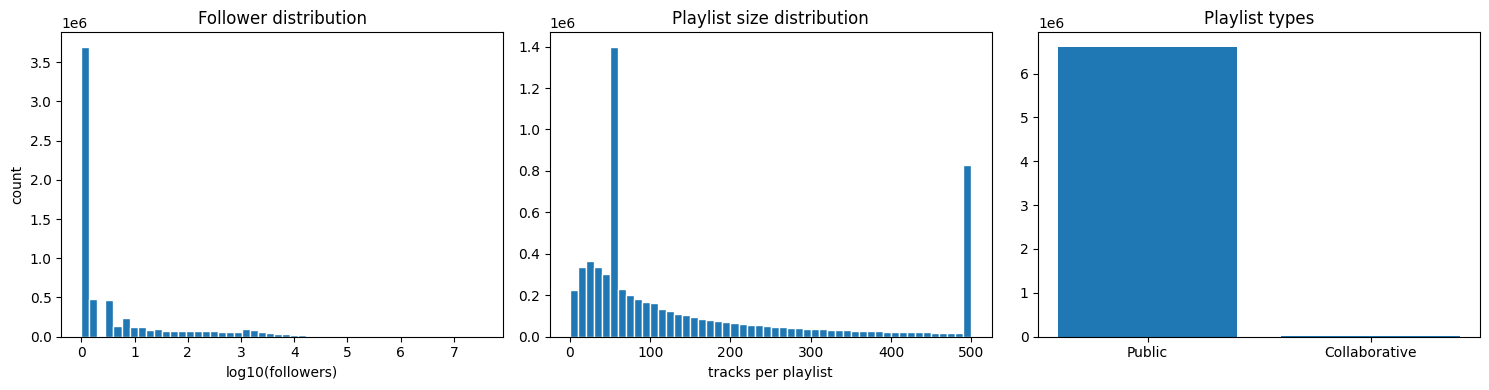

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(np.log10(playlists["followers_total"].clip(lower=1)), bins=50, edgecolor="white")
axes[0].set_xlabel("log10(followers)")
axes[0].set_ylabel("count")
axes[0].set_title("Follower distribution")

axes[1].hist(playlists["tracks_total"].clip(upper=500), bins=50, edgecolor="white")
axes[1].set_xlabel("tracks per playlist")
axes[1].set_title("Playlist size distribution")

axes[2].bar(["Public", "Collaborative"], [
    playlists["public"].sum(),
    playlists["collaborative"].sum(),
])
axes[2].set_title("Playlist types")

plt.tight_layout()
plt.show()

## Filtering threshold analysis

How many playlists and interactions survive at various follower thresholds?

In [21]:
thresholds = [0, 10, 50, 100, 500, 1000, 5000, 10_000, 50_000, 100_000]
followers = playlists["followers_total"]
tracks_total = playlists["tracks_total"]

rows = []
for t in thresholds:
    mask = followers >= t
    n_pl = mask.sum()
    est_interactions = tracks_total[mask].sum()
    rows.append({"min_followers": t, "playlists": n_pl, "est_interactions": est_interactions})

threshold_df = pd.DataFrame(rows)
threshold_df["playlists_fmt"] = threshold_df["playlists"].map("{:,}".format)
threshold_df["interactions_fmt"] = threshold_df["est_interactions"].map("{:,}".format)
threshold_df

,min_followers,playlists,est_interactions,playlists_fmt,interactions_fmt
0,0,6608471,1698366949,"6,608,471","1,698,366,949"
1,10,1555189,354526830,"1,555,189","354,526,830"
2,50,1074000,169639036,"1,074,000","169,639,036"
3,100,918312,140570448,"918,312","140,570,448"
4,500,582232,90256000,"582,232","90,256,000"
5,1000,471572,73226887,"471,572","73,226,887"
6,5000,133402,20470208,"133,402","20,470,208"
7,10000,74082,11064678,"74,082","11,064,678"
8,50000,16932,2267764,"16,932","2,267,764"
9,100000,8752,1090705,"8,752","1,090,705"


## Data quality: episodes, local files, null track_rowids

These queries hit the 1.7B-row playlist_tracks table. They may be slow — we sample or use indexed columns.

In [19]:
quality = pd.read_sql("""
    SELECT 
        COUNT(*) as total,
        SUM(is_episode) as episodes,
        SUM(is_local) as local_files,
        SUM(track_rowid IS NULL) as null_track_rowids
    FROM playlist_tracks
""", conn)
quality

,total,episodes,local_files,null_track_rowids
0,1698443099,1363945,3346851,8430451


## Top-N playlist analysis

Full-table queries on 1.7B rows are intractable. Instead, we take the top N playlists by follower count and fetch only their tracks. This is fast because `playlist_rowid` is the primary key prefix on `playlist_tracks`.

In [22]:
# Load our existing training track_rowids for overlap check
training_data = pd.read_parquet(
    Path("..") / "data/engineered/training_pop40_genres.parquet",
    columns=["track_rowid"],
)
training_track_ids = set(training_data["track_rowid"])
print(f"Existing training set: {len(training_track_ids):,} tracks")

Existing training set: 561,314 tracks


In [44]:
import time


def fetch_top_n_tracks(conn, n):
    """Fetch all valid track_rowids for the top N playlists by followers.
    
    Returns a DataFrame of (playlist_rowid, track_rowid) pairs.
    Uses a subquery instead of IN(...) to avoid SQLite's variable limit.
    """
    query = """
        SELECT pt.playlist_rowid, pt.track_rowid
        FROM playlist_tracks pt
        WHERE pt.playlist_rowid IN (
            SELECT rowid FROM playlists ORDER BY followers_total DESC LIMIT ?
        )
          AND pt.is_episode = 0
          AND pt.is_local = 0
          AND pt.track_rowid IS NOT NULL
    """
    return pd.read_sql(query, conn, params=[n])

In [49]:
N_VALUES = [2 ** n for n in range(8, 18)]
results = []

for n in N_VALUES:
    t0 = time.time()
    interactions = fetch_top_n_tracks(conn, n)
    elapsed = time.time() - t0
    
    unique_tracks = interactions["track_rowid"].nunique()
    overlap = len(set(interactions["track_rowid"]) & training_track_ids)
    
    # interactions per track
    track_counts = interactions["track_rowid"].value_counts()
    
    results.append({
        "top_n": n,
        "interactions": len(interactions),
        "unique_tracks": unique_tracks,
        "pop40_overlap": overlap,
        "pop40_coverage_pct": 100 * overlap / len(training_track_ids),
        "median_interactions": track_counts.median(),
        "p25_interactions": track_counts.quantile(0.25),
        "p75_interactions": track_counts.quantile(0.75),
        "tracks_with_1": (track_counts == 1).sum(),
        "pct_with_1": 100 * (track_counts == 1).sum() / unique_tracks,
        "time_s": elapsed,
    })
    print(f"top {n:>5}: {len(interactions):>10,} interactions, "
          f"{unique_tracks:>8,} tracks, "
          f"{100*overlap/len(training_track_ids):>5.1f}% pop40 coverage, "
          f"{elapsed:.1f}s")

results_df = pd.DataFrame(results)
results_df

top   256:     28,375 interactions,   20,420 tracks,   2.9% pop40 coverage, 0.0s
top   512:     53,752 interactions,   36,745 tracks,   5.1% pop40 coverage, 0.1s
top  1024:    105,620 interactions,   66,316 tracks,   8.4% pop40 coverage, 0.1s
top  2048:    214,556 interactions,  126,014 tracks,  13.7% pop40 coverage, 0.3s
top  4096:    442,663 interactions,  249,541 tracks,  22.2% pop40 coverage, 0.6s
top  8192:  1,008,953 interactions,  528,481 tracks,  33.9% pop40 coverage, 1.3s
top 16384:  2,149,684 interactions, 1,025,154 tracks,  47.9% pop40 coverage, 2.7s
top 32768:  4,547,241 interactions, 1,913,794 tracks,  62.2% pop40 coverage, 5.7s
top 65536:  9,614,981 interactions, 3,523,368 tracks,  74.8% pop40 coverage, 12.1s
top 131072: 19,750,750 interactions, 6,163,438 tracks,  84.4% pop40 coverage, 224.2s


,top_n,interactions,unique_tracks,pop40_overlap,pop40_coverage_pct,median_interactions,p25_interactions,p75_interactions,tracks_with_1,pct_with_1,time_s
0,256,28375,20420,16130,2.873614,1.0,1.0,1.0,16452,80.568071,0.036806
1,512,53752,36745,28445,5.067574,1.0,1.0,1.0,28964,78.824330,0.066734
2,1024,105620,66316,46896,8.354682,1.0,1.0,1.0,50381,75.971108,0.139434
3,2048,214556,126014,76978,13.713893,1.0,1.0,2.0,93662,74.326662,0.277334
4,4096,442663,249541,124596,22.197202,1.0,1.0,2.0,184419,73.903286,0.576504
5,8192,1008953,528481,190393,33.919161,1.0,1.0,2.0,374245,70.815223,1.265271
6,16384,2149684,1025154,268952,47.914714,1.0,1.0,2.0,722491,70.476338,2.748945
7,32768,4547241,1913794,349247,62.219542,1.0,1.0,2.0,1300555,67.956896,5.698000
8,65536,9614981,3523368,420058,74.834763,1.0,1.0,2.0,2317141,65.764944,12.055934
9,131072,19750750,6163438,473553,84.365079,1.0,1.0,2.0,3853889,62.528235,224.159664


## Interactions-per-track distribution

Pick a top-N value from above and visualize how many playlists each track appears in.

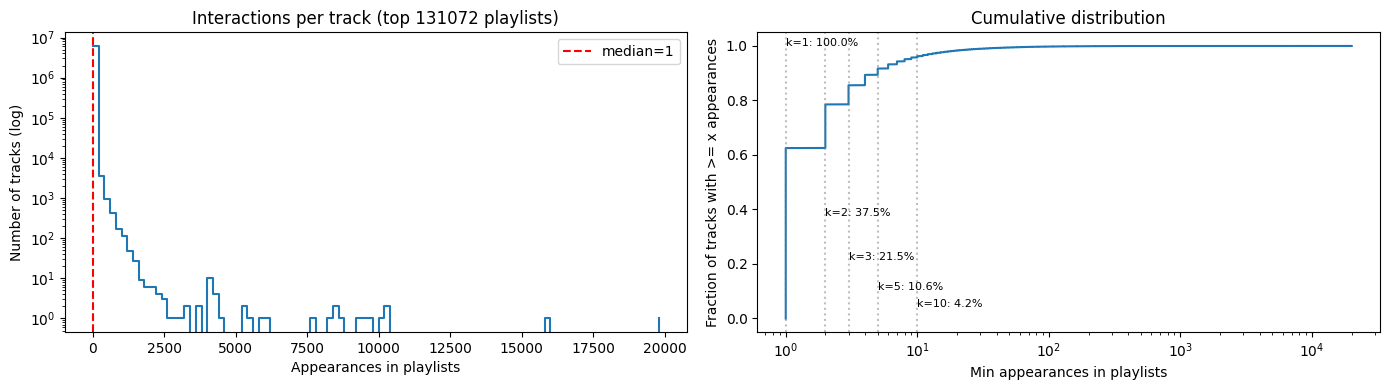


Interactions-per-track percentiles:
  p10: 1
  p25: 1
  p50: 1
  p75: 2
  p90: 5
  p95: 8
  p99: 31


In [71]:
# --- adjust this after reviewing the table above ---
CHOSEN_N = 131072

interactions = fetch_top_n_tracks(conn, CHOSEN_N)
track_counts = interactions["track_rowid"].value_counts()
_counts, _bins = np.histogram(track_counts.values, bins=100)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].step(_bins[:-1], _counts, where="post")
axes[0].set_yscale("log")
axes[0].set_xlabel("Appearances in playlists")
axes[0].set_ylabel("Number of tracks (log)")
axes[0].set_title(f"Interactions per track (top {CHOSEN_N} playlists)")
axes[0].axvline(track_counts.median(), color="red", ls="--", label=f"median={track_counts.median():.0f}")
axes[0].legend()

# CDF
sorted_counts = np.sort(track_counts.values)
cdf = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)
axes[1].plot(sorted_counts, cdf)
axes[1].set_xlabel("Min appearances in playlists")
axes[1].set_ylabel("Fraction of tracks with >= x appearances")
axes[1].set_title("Cumulative distribution")
axes[1].set_xscale("log")
for k in [1, 2, 3, 5, 10]:
    frac = (track_counts >= k).mean()
    axes[1].axvline(k, color="gray", ls=":", alpha=0.5)
    axes[1].annotate(f"k={k}: {100*frac:.1f}%", (k, frac), fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nInteractions-per-track percentiles:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"  p{p}: {track_counts.quantile(p/100):.0f}")

## K-core filtering

After choosing a top-N, apply a minimum interactions threshold to remove sparse tracks. This gives us the dense core for BPR training.

In [70]:
MIN_INTERACTIONS_VALUES = [1, 2, 3, 5, 10, 20]

rows = []
for k in MIN_INTERACTIONS_VALUES:
    surviving_tracks = track_counts[track_counts >= k]
    surviving_ids = set(surviving_tracks.index)
    filtered = interactions[interactions["track_rowid"].isin(surviving_ids)]
    n_playlists = filtered["playlist_rowid"].nunique()
    n_tracks = len(surviving_tracks)
    n_interactions = len(filtered)
    overlap = len(surviving_ids & training_track_ids)

    rows.append({
        "min_k": k,
        "tracks": n_tracks,
        "playlists": n_playlists,
        "interactions": n_interactions,
        "pop40_overlap": overlap,
        "pop40_coverage_pct": 100 * overlap / len(training_track_ids),
        "sparsity": 1 - n_interactions / (n_playlists * n_tracks) if n_playlists * n_tracks > 0 else 1,
        "avg_tracks_per_playlist": n_interactions / n_playlists if n_playlists > 0 else 0,
        "avg_playlists_per_track": n_interactions / n_tracks if n_tracks > 0 else 0,
    })

kcore_df = pd.DataFrame(rows)
kcore_df

,min_k,tracks,playlists,interactions,pop40_overlap,pop40_coverage_pct,sparsity,avg_tracks_per_playlist,avg_playlists_per_track
0,1,6163438,130359,19750750,473553,84.365079,0.999975,151.510444,3.204502
1,2,2309549,129698,15896861,397950,70.896147,0.999947,122.568282,6.883102
2,3,1322493,128742,13922749,336537,59.955212,0.999918,108.144576,10.527654
3,5,653864,126488,11681410,250346,44.599992,0.999859,92.351923,17.865198
4,10,261056,121016,9186151,143463,25.558422,0.999709,75.908566,35.188431
5,20,108219,112305,7169971,69955,12.462721,0.999410,63.843738,66.254271


In [ ]:
conn.close()
print("Done.")